In [1]:
import numpy as np
import os

# ✅ 改成你解壓後的檔案位置
npy_path = r"C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy"

assert os.path.exists(npy_path), f"找不到檔案：{npy_path}"

D = np.load(npy_path, mmap_mode="r")  # memmap：不會整包載入 RAM
print("Loaded:", npy_path)
print("shape:", D.shape, "dtype:", D.dtype)

Ny, Nx, Ky, Kx = D.shape
print("Scan grid (Ny,Nx) =", (Ny, Nx), " | DP size (Ky,Kx) =", (Ky, Kx))

Loaded: C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy
shape: (256, 256, 128, 128) dtype: float32
Scan grid (Ny,Nx) = (256, 256)  | DP size (Ky,Kx) = (128, 128)


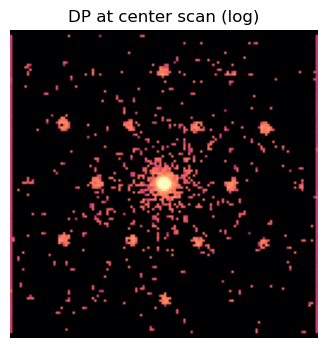

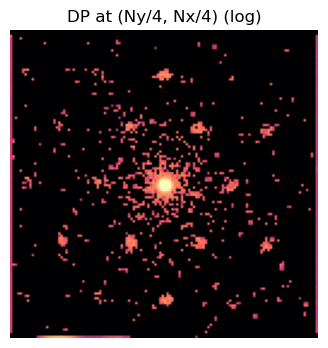

Assumed DP center (cy0,cx0) = (63.5, 63.5)


In [2]:
import matplotlib.pyplot as plt
def show_dp(dp, title="", log=True):
    img = dp.astype(np.float32)
    if log:
        img = np.log1p(img)
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="magma")
    plt.title(title)
    plt.axis("off")
    plt.show()

# 隨便看幾個點
show_dp(D[Ny//2, Nx//2], "DP at center scan (log)")
show_dp(D[Ny//4, Nx//4], "DP at (Ny/4, Nx/4) (log)")
cy0, cx0 = (Ky-1)/2.0, (Kx-1)/2.0
print("Assumed DP center (cy0,cx0) =", (cy0, cx0))

Reference ROI: (40, 120, 40, 120)


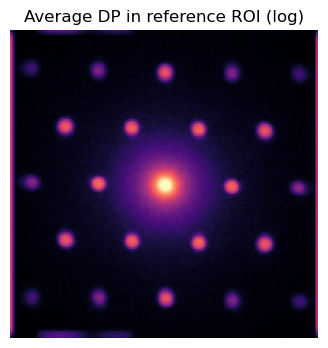

In [3]:
# 你可以改這個 reference box（選擇單一晶相、遠離界面）
x0, x1 = 40, 120
y0, y1 = 40, 120

print("Reference ROI:", (y0,y1,x0,x1))
def mean_dp_in_roi(D, y0,y1,x0,x1, step=2):
    # step=2 表示每隔2個像素取一次，快很多；你也可用 step=1 更精準
    acc = np.zeros((Ky,Kx), dtype=np.float64)
    cnt = 0
    for y in range(y0, y1, step):
        for x in range(x0, x1, step):
            acc += D[y,x]
            cnt += 1
    return acc/cnt

avg_dp = mean_dp_in_roi(D, y0,y1,x0,x1, step=2)
show_dp(avg_dp, "Average DP in reference ROI (log)")

Top peak candidates: 6


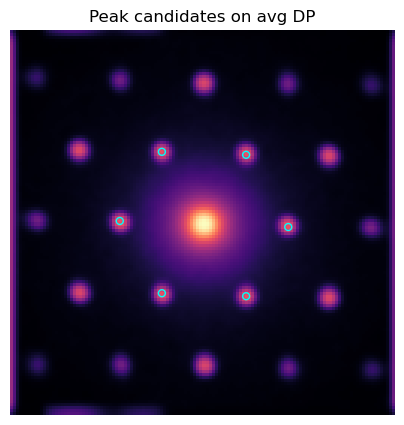

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, maximum_filter
img = np.log1p(avg_dp.astype(np.float32))
img = gaussian_filter(img, sigma=1.0)

yy, xx = np.mgrid[0:Ky, 0:Kx]
rr = np.sqrt((yy-cy0)**2 + (xx-cx0)**2)

r_exclude = 10  # 排除中心半徑（你可依照 DP 調整）
mask_ring = rr > r_exclude

# 找局部極大值
neigh = 7  # 鄰域大小（越大越不容易抓到雜訊峰）
mx = maximum_filter(img, size=neigh)
is_peak = (img == mx) & mask_ring

peak_coords = np.argwhere(is_peak)
peak_vals = img[is_peak]

# 取最亮的前 N 個候選峰
Npeaks = 6
order = np.argsort(peak_vals)[::-1]
peak_coords = peak_coords[order[:Npeaks]]
peak_vals = peak_vals[order[:Npeaks]]

print("Top peak candidates:", len(peak_coords))

# 畫在圖上檢查
plt.figure(figsize=(5,5))
plt.imshow(img, cmap="magma")
plt.scatter(peak_coords[:,1], peak_coords[:,0], s=25, facecolors="none", edgecolors="cyan")
plt.title("Peak candidates on avg DP")
plt.axis("off")
plt.show()

Selected g1 (vx,vy)= (-27.5, -0.5) r= 27.504545078950134 angle(deg)= -178.95837332399003
Selected g2 (vx,vy)= (-13.5, -23.5) r= 27.101660465735304 angle(deg)= -119.87599269168943


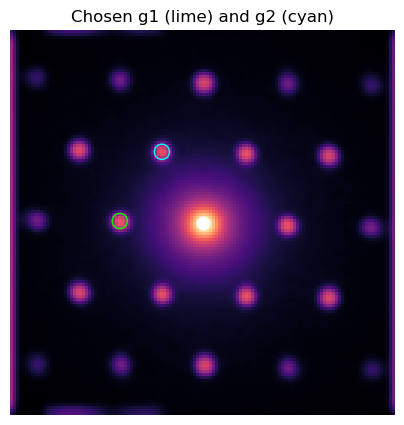

In [5]:
# 把候選 peak 轉成向量（相對中心）
vecs = []
for (py, px), val in zip(peak_coords, peak_vals):
    vx = px - cx0
    vy = py - cy0
    r = np.sqrt(vx**2 + vy**2)
    ang = np.arctan2(vy, vx)
    vecs.append((vx, vy, r, ang, val))
vecs = np.array(vecs, dtype=float)

# 取最亮的當 g1
g1 = vecs[0]  # [vx, vy, r, ang, val]
vx1, vy1, r1, ang1, _ = g1

# 在其他候選中找 g2：半徑要接近，角度差接近 60° 或 120°
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

best = None
best_score = 1e9
for cand in vecs[1:]:
    vx2, vy2, r2, ang2, _ = cand
    if r2 < 1e-6: 
        continue
    dr = abs(r2 - r1) / r1
    dang = abs(wrap_pi(ang2 - ang1))
    # 跟 60° 或 120° 的接近程度
    score_ang = min(abs(dang - np.pi/3), abs(dang - 2*np.pi/3))
    # 綜合：半徑相近優先 + 角度接近優先
    score = (dr/0.15)**2 + (score_ang/0.3)**2
    if score < best_score:
        best_score = score
        best = cand

g2 = best
print("Selected g1 (vx,vy)=", (vx1,vy1), "r=", r1, "angle(deg)=", ang1*180/np.pi)
print("Selected g2 (vx,vy)=", (g2[0],g2[1]), "r=", g2[2], "angle(deg)=", g2[3]*180/np.pi)

# 視覺確認
plt.figure(figsize=(5,5))
plt.imshow(img, cmap="magma")
plt.scatter([cx0+vx1, cx0+g2[0]],[cy0+vy1, cy0+g2[1]], s=120, facecolors="none", edgecolors=["lime","cyan"])
plt.scatter([cx0],[cy0], s=80, c="white")
plt.title("Chosen g1 (lime) and g2 (cyan)")
plt.axis("off")
plt.show()

Selected g1+ (vx,vy) = (-27.5, -0.5)  r= 27.504545078950134  angle(deg)= -178.95837332399003
Selected g1- (vx,vy) = (28.5, 1.5)  r= 28.53944638566067  angle(deg)= 3.0127875041833403
Selected g2+ (vx,vy) = (-13.5, -23.5)  r= 27.101660465735304  angle(deg)= -119.87599269168943
Selected g2- (vx,vy) = (14.5, 24.5)  r= 28.469281690973517  angle(deg)= 59.3813945910906
g2 selection score = 0.1440040551134833


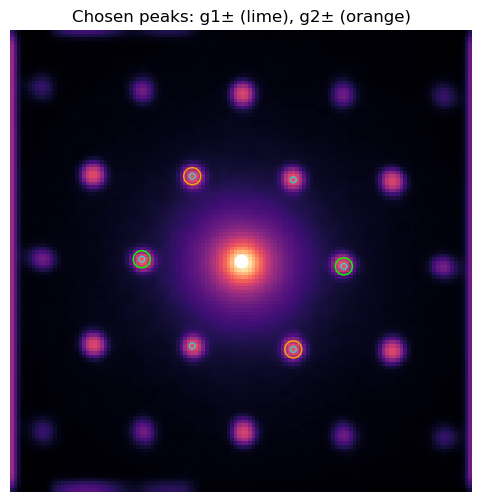

In [6]:
# === Robust selection of g1/g2 with ±g pairing ===

# 把候選 peak 轉成向量（相對中心）
vecs = []
for (py, px), val in zip(peak_coords, peak_vals):
    vx = px - cx0
    vy = py - cy0
    r = np.sqrt(vx**2 + vy**2)
    ang = np.arctan2(vy, vx)
    vecs.append((vx, vy, r, ang, val, py, px))  # 也保留原始座標
vecs = np.array(vecs, dtype=float)

def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

# 方便用：給定 (vx,vy)，找最接近的「對稱峰」(-vx,-vy)
def find_antipeak(vecs, vx, vy):
    target = np.array([-vx, -vy])
    cand = vecs[:, 0:2]
    d2 = np.sum((cand - target[None, :])**2, axis=1)
    idx = int(np.argmin(d2))
    return vecs[idx], np.sqrt(d2[idx])

# ----- 1) 從最亮的前幾個峰裡，找一個「有明顯對稱峰」的 g1 -----
K_try = min(10, len(vecs))  # 只在前10亮峰找g1候選
g1 = None
for i in range(K_try):
    vx, vy, r, ang, val, py, px = vecs[i]
    anti, err = find_antipeak(vecs, vx, vy)

    # err 門檻：允許對稱峰偏差（以像素為單位）
    # 這個通常設 2~5 px 之間，看你的 peak 寬度
    if err < 4.0:
        g1 = vecs[i]
        g1m = anti
        break

if g1 is None:
    # 如果找不到對稱峰（少見），就退回用最亮峰
    g1 = vecs[0]
    g1m, _ = find_antipeak(vecs, g1[0], g1[1])

vx1, vy1, r1, ang1, val1, py1, px1 = g1
vx1m, vy1m, r1m, ang1m, val1m, py1m, px1m = g1m

# ----- 2) 找 g2：半徑接近 + 角度差 ~ 60°/120° + 也要有對稱峰 -----
best = None
best_score = 1e18
best_m = None

for cand in vecs:
    vx2, vy2, r2, ang2, val2, py2, px2 = cand

    # 排除自己/太近
    if r2 < 1e-6:
        continue
    if (vx2 == vx1) and (vy2 == vy1):
        continue

    # 半徑相近
    dr = abs(r2 - r1) / r1

    # 角度差接近 60° 或 120°
    dang = abs(wrap_pi(ang2 - ang1))
    score_ang = min(abs(dang - np.pi/3), abs(dang - 2*np.pi/3))

    # 確保 g2 也有對稱峰
    anti2, err2 = find_antipeak(vecs, vx2, vy2)
    if err2 > 4.0:
        continue

    # 綜合分數（你可調權重）
    score = (dr/0.12)**2 + (score_ang/0.25)**2 + (err2/4.0)**2

    if score < best_score:
        best_score = score
        best = cand
        best_m = anti2

# 若真的找不到，就退回原本規則（不建議，但保底）
if best is None:
    best_score = 1e9
    for cand in vecs[1:]:
        vx2, vy2, r2, ang2, val2, py2, px2 = cand
        if r2 < 1e-6:
            continue
        dr = abs(r2 - r1) / r1
        dang = abs(wrap_pi(ang2 - ang1))
        score_ang = min(abs(dang - np.pi/3), abs(dang - 2*np.pi/3))
        score = (dr/0.15)**2 + (score_ang/0.3)**2
        if score < best_score:
            best_score = score
            best = cand
    best_m, _ = find_antipeak(vecs, best[0], best[1])

g2 = best
g2m = best_m

vx2, vy2, r2, ang2, val2, py2, px2 = g2
vx2m, vy2m, r2m, ang2m, val2m, py2m, px2m = g2m

print("Selected g1+ (vx,vy) =", (vx1,vy1), " r=", r1, " angle(deg)=", ang1*180/np.pi)
print("Selected g1- (vx,vy) =", (vx1m,vy1m), " r=", r1m, " angle(deg)=", ang1m*180/np.pi)
print("Selected g2+ (vx,vy) =", (vx2,vy2), " r=", r2, " angle(deg)=", ang2*180/np.pi)
print("Selected g2- (vx,vy) =", (vx2m,vy2m), " r=", r2m, " angle(deg)=", ang2m*180/np.pi)
print("g2 selection score =", best_score)

# === 產生四個初始 peak 位置 (DP pixel coordinates) ===
# 這四個會拿去做 ±g tracking
p1y0, p1x0 = cy0 + vy1,  cx0 + vx1   # g1+
p1m_y0, p1m_x0 = cy0 + vy1m, cx0 + vx1m  # g1-
p2y0, p2x0 = cy0 + vy2,  cx0 + vx2   # g2+
p2m_y0, p2m_x0 = cy0 + vy2m, cx0 + vx2m  # g2-

# 視覺確認：把候選峰點出來 + 標記四個峰
plt.figure(figsize=(6,6))
plt.imshow(img, cmap="magma")
plt.scatter(vecs[:,6], vecs[:,5], s=18, facecolors="none", edgecolors="cyan", alpha=0.7)  # 所有候選
plt.scatter([p1x0, p1m_x0, p2x0, p2m_x0],
            [p1y0, p1m_y0, p2y0, p2m_y0],
            s=150, facecolors="none",
            edgecolors=["lime","lime","orange","orange"])
plt.scatter([cx0],[cy0], s=80, c="white")
plt.title("Chosen peaks: g1± (lime), g2± (orange)")
plt.axis("off")
plt.show()

In [7]:
import numpy as np

def subpixel_peak_centroid(img, y0, x0, win=13, eps=1e-12):
    """
    在 (y0, x0) 附近用 win×win 視窗做加權質心，回傳 (yc, xc) 的 float。
    若超出邊界或視窗內沒有有效權重，回傳 (nan, nan)。

    img: 2D array
    y0, x0: 初始 peak 座標（可 int/float，但會以 round 後當中心取窗）
    win: 視窗大小（建議奇數）
    """
    H, W = img.shape
    if not np.isfinite(y0) or not np.isfinite(x0):
        return np.nan, np.nan

    y0i = int(np.round(y0))
    x0i = int(np.round(x0))
    r = win // 2

    y1 = max(0, y0i - r)
    y2 = min(H, y0i + r + 1)
    x1 = max(0, x0i - r)
    x2 = min(W, x0i + r + 1)

    roi = img[y1:y2, x1:x2].astype(np.float32)

    # 權重：把背景拉到 >=0，避免負值影響質心
    # （很多 DP 取 log / 濾波後可能會有小負值）
    m = np.nanmin(roi)
    w = roi - m
    w[w < 0] = 0.0

    s = np.nansum(w)
    if not np.isfinite(s) or s <= eps:
        return np.nan, np.nan

    yy, xx = np.mgrid[y1:y2, x1:x2]
    yc = np.nansum(yy * w) / s
    xc = np.nansum(xx * w) / s
    return float(yc), float(xc)

In [8]:
from scipy.ndimage import gaussian_filter
import numpy as np

# ===== parameters =====
win = 13
sigma_dp = 0.6     # DP smoothing before centroid
dg_thr = 1.0       # gate threshold (DP-pixel units): 0.8~1.5 可調
max_fail = 3       # consecutive fails then reset to initial peak positions

# ===== output arrays =====
g1x = np.full((Ny, Nx), np.nan, dtype=np.float32)
g1y = np.full((Ny, Nx), np.nan, dtype=np.float32)
g2x = np.full((Ny, Nx), np.nan, dtype=np.float32)
g2y = np.full((Ny, Nx), np.nan, dtype=np.float32)

for y in range(Ny):

    # 每列重置初值（避免錯峰一路傳下去）
    p1p_y, p1p_x = p1y0,  p1x0
    p1m_y, p1m_x = p1m_y0, p1m_x0
    p2p_y, p2p_x = p2y0,  p2x0
    p2m_y, p2m_x = p2m_y0, p2m_x0

    # 上一個成功的 g（用來 gate）
    prev1x = np.nan; prev1y = np.nan
    prev2x = np.nan; prev2y = np.nan

    fail1 = 0
    fail2 = 0

    for x in range(Nx):

        dp = gaussian_filter(D[y, x].astype(np.float32), sigma=sigma_dp)

        # ---------- g1 (+/-) ----------
        y1p, x1p = subpixel_peak_centroid(dp, p1p_y, p1p_x, win=win)
        y1m, x1m = subpixel_peak_centroid(dp, p1m_y, p1m_x, win=win)

        ok1 = np.isfinite(x1p) & np.isfinite(y1p) & np.isfinite(x1m) & np.isfinite(y1m)
        if ok1:
            gx1 = ((x1p - cx0) - (x1m - cx0)) / 2.0
            gy1 = ((y1p - cy0) - (y1m - cy0)) / 2.0

            # gate: reject big jumps vs previous accepted g
            if np.isfinite(prev1x):
                dg = np.sqrt((gx1 - prev1x)**2 + (gy1 - prev1y)**2)
                if dg > dg_thr:
                    ok1 = False

        if ok1:
            g1x[y, x] = gx1
            g1y[y, x] = gy1
            prev1x, prev1y = gx1, gy1
            fail1 = 0

            # update initial guess for next pixel
            p1p_y, p1p_x = y1p, x1p
            p1m_y, p1m_x = y1m, x1m

        else:
            g1x[y, x] = np.nan
            g1y[y, x] = np.nan
            fail1 += 1

            # too many fails -> reset starting guess
            if fail1 >= max_fail:
                p1p_y, p1p_x = p1y0,  p1x0
                p1m_y, p1m_x = p1m_y0, p1m_x0
                prev1x, prev1y = np.nan, np.nan
                fail1 = 0

        # ---------- g2 (+/-) ----------
        y2p, x2p = subpixel_peak_centroid(dp, p2p_y, p2p_x, win=win)
        y2m, x2m = subpixel_peak_centroid(dp, p2m_y, p2m_x, win=win)

        ok2 = np.isfinite(x2p) & np.isfinite(y2p) & np.isfinite(x2m) & np.isfinite(y2m)
        if ok2:
            gx2 = ((x2p - cx0) - (x2m - cx0)) / 2.0
            gy2 = ((y2p - cy0) - (y2m - cy0)) / 2.0

            if np.isfinite(prev2x):
                dg = np.sqrt((gx2 - prev2x)**2 + (gy2 - prev2y)**2)
                if dg > dg_thr:
                    ok2 = False

        if ok2:
            g2x[y, x] = gx2
            g2y[y, x] = gy2
            prev2x, prev2y = gx2, gy2
            fail2 = 0

            p2p_y, p2p_x = y2p, x2p
            p2m_y, p2m_x = y2m, x2m

        else:
            g2x[y, x] = np.nan
            g2y[y, x] = np.nan
            fail2 += 1

            if fail2 >= max_fail:
                p2p_y, p2p_x = p2y0,  p2x0
                p2m_y, p2m_x = p2m_y0, p2m_x0
                prev2x, prev2y = np.nan, np.nan
                fail2 = 0

print("done ±g tracking with gate")
print("finite fraction g1:", np.isfinite(g1x).mean(), "g2:", np.isfinite(g2x).mean())

done ±g tracking with gate
finite fraction g1: 0.8363189697265625 g2: 0.8479156494140625


In [13]:
import numpy as np
from scipy.ndimage import gaussian_filter

g1mag = np.sqrt(g1x**2 + g1y**2)
g2mag = np.sqrt(g2x**2 + g2y**2)
finite = np.isfinite(g1mag) & np.isfinite(g2mag)

# 用分位數自動排除異常區（底部爛區通常會被排掉）
g1_lo, g1_hi = np.nanpercentile(g1mag[finite], [5, 95])
g2_lo, g2_hi = np.nanpercentile(g2mag[finite], [5, 95])

quality = finite & (g1mag >= g1_lo) & (g1mag <= g1_hi) & (g2mag >= g2_lo) & (g2mag <= g2_hi)
print("quality fraction:", quality.mean())

def nan_gaussian(arr, m, sigma):
    arr0 = np.where(m, arr, 0.0).astype(np.float32)
    w = m.astype(np.float32)
    arr_blur = gaussian_filter(arr0, sigma=sigma)
    w_blur = gaussian_filter(w, sigma=sigma)
    out = arr_blur / np.maximum(w_blur, 1e-12)
    out[~m] = np.nan
    return out

sigma_g = 1.0  # 0.8~1.5 可調
g1x_s = nan_gaussian(g1x, quality, sigma_g)
g1y_s = nan_gaussian(g1y, quality, sigma_g)
g2x_s = nan_gaussian(g2x, quality, sigma_g)
g2y_s = nan_gaussian(g2y, quality, sigma_g)

print("done nan-aware smoothing")

quality fraction: 0.6188507080078125
done nan-aware smoothing


In [14]:
import numpy as np

def remove_scan_stripe_linear(arr, mask=None):
    Ny, Nx = arr.shape
    out = arr.copy()
    x = np.arange(Nx)

    for y in range(Ny):
        row = arr[y]
        if mask is not None:
            m = mask[y] & np.isfinite(row)
        else:
            m = np.isfinite(row)

        if np.sum(m) < 20:
            continue

        a, b = np.polyfit(x[m], row[m], 1)
        out[y] = row - (a*x + b)
    return out

m = np.isfinite(g1x_s) & np.isfinite(g1y_s) & np.isfinite(g2x_s) & np.isfinite(g2y_s)

g1x_c = remove_scan_stripe_linear(g1x_s, mask=m)
g1y_c = remove_scan_stripe_linear(g1y_s, mask=m)
g2x_c = remove_scan_stripe_linear(g2x_s, mask=m)
g2y_c = remove_scan_stripe_linear(g2y_s, mask=m)

valid = np.isfinite(g1x_c) & np.isfinite(g1y_c) & np.isfinite(g2x_c) & np.isfinite(g2y_c)
print("valid fraction after detrend:", valid.mean())

valid fraction after detrend: 0.6188507080078125


In [15]:
import numpy as np

# mean G over valid
g1x_mean = np.nanmedian(g1x_c[valid]); g1y_mean = np.nanmedian(g1y_c[valid])
g2x_mean = np.nanmedian(g2x_c[valid]); g2y_mean = np.nanmedian(g2y_c[valid])

Gmean = np.array([[g1x_mean, g2x_mean],
                  [g1y_mean, g2y_mean]], dtype=np.float64)

# reference G0（用 valid 區 robust median）
g1x0 = np.nanmedian(g1x_c[valid]); g1y0 = np.nanmedian(g1y_c[valid])
g2x0 = np.nanmedian(g2x_c[valid]); g2y0 = np.nanmedian(g2y_c[valid])

G0 = np.array([[g1x0, g2x0],
               [g1y0, g2y0]], dtype=np.float64)

A = G0 @ np.linalg.inv(Gmean)
print("A (affine correction) =\n", A)

g1x_cc = np.full_like(g1x_c, np.nan, dtype=np.float32)
g1y_cc = np.full_like(g1y_c, np.nan, dtype=np.float32)
g2x_cc = np.full_like(g2x_c, np.nan, dtype=np.float32)
g2y_cc = np.full_like(g2y_c, np.nan, dtype=np.float32)

Ny, Nx = g1x_c.shape
for y in range(Ny):
    for x in range(Nx):
        if not valid[y, x]:
            continue
        G = np.array([[g1x_c[y,x], g2x_c[y,x]],
                      [g1y_c[y,x], g2y_c[y,x]]], dtype=np.float64)
        Gc = A @ G
        g1x_cc[y,x], g2x_cc[y,x] = Gc[0,0], Gc[0,1]
        g1y_cc[y,x], g2y_cc[y,x] = Gc[1,0], Gc[1,1]

valid2 = np.isfinite(g1x_cc)&np.isfinite(g1y_cc)&np.isfinite(g2x_cc)&np.isfinite(g2y_cc)
print("valid2 fraction:", valid2.mean())

A (affine correction) =
 [[1. 0.]
 [0. 1.]]
valid2 fraction: 0.6188507080078125


In [17]:
import numpy as np
from scipy.ndimage import gaussian_filter

g1x_use, g1y_use = g1x_cc, g1y_cc
g2x_use, g2y_use = g2x_cc, g2y_cc
valid_use = valid2

# reference G0 (again, but now from corrected g)
g1x0 = np.nanmedian(g1x_use[valid_use]); g1y0 = np.nanmedian(g1y_use[valid_use])
g2x0 = np.nanmedian(g2x_use[valid_use]); g2y0 = np.nanmedian(g2y_use[valid_use])

G0 = np.array([[g1x0, g2x0],
               [g1y0, g2y0]], dtype=np.float64)
G0_inv = np.linalg.inv(G0)

Ny, Nx = g1x_use.shape
eps_xx = np.full((Ny, Nx), np.nan, dtype=np.float32)
eps_yy = np.full((Ny, Nx), np.nan, dtype=np.float32)
theta_deg = np.full((Ny, Nx), np.nan, dtype=np.float32)

I = np.eye(2)

for y in range(Ny):
    for x in range(Nx):
        if not valid_use[y, x]:
            continue

        G = np.array([[g1x_use[y,x], g2x_use[y,x]],
                      [g1y_use[y,x], g2y_use[y,x]]], dtype=np.float64)

        A = G @ G0_inv         # F^{-T}
        F = np.linalg.inv(A).T # F

        E = 0.5*(F + F.T) - I
        eps_xx[y,x] = E[0,0]
        eps_yy[y,x] = E[1,1]

        w = 0.5*(F[1,0] - F[0,1])
        theta_deg[y,x] = w * 180/np.pi

# final NaN-aware smoothing (light)
def nan_gaussian(arr, m, sigma):
    arr0 = np.where(m, arr, 0.0).astype(np.float32)
    w = m.astype(np.float32)
    arr_blur = gaussian_filter(arr0, sigma=sigma)
    w_blur = gaussian_filter(w, sigma=sigma)
    out = arr_blur / np.maximum(w_blur, 1e-12)
    out[~m] = np.nan
    return out

eps_xx = nan_gaussian(eps_xx, valid_use, sigma=1.0)
eps_yy = nan_gaussian(eps_yy, valid_use, sigma=1.0)
theta_deg = nan_gaussian(theta_deg, valid_use, sigma=1.0)

print("done tensor strain")

done tensor strain


C:\Users\User\AppData\Local\Temp\ipykernel_48564\4014468565.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


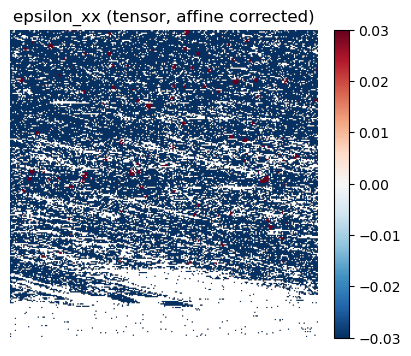

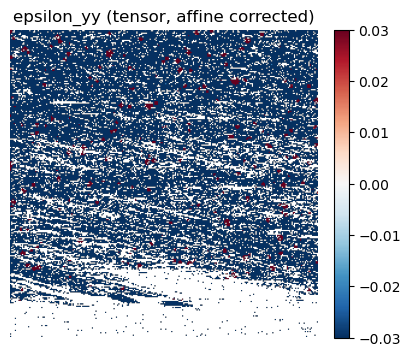

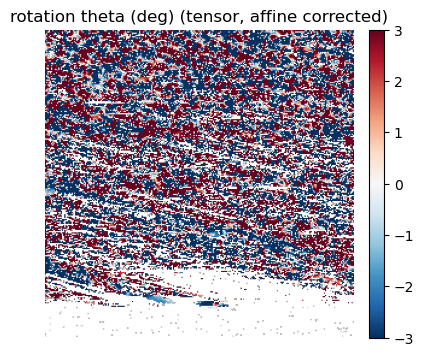

In [18]:
import matplotlib.pyplot as plt

def show_map(arr, title, vmin, vmax, cmap_name="RdBu_r", figsize=(5,4)):
    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad(alpha=0.0)
    plt.figure(figsize=figsize)
    im = plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.show()

show_map(eps_xx, "epsilon_xx (tensor, affine corrected)", -0.03, 0.03)
show_map(eps_yy, "epsilon_yy (tensor, affine corrected)", -0.03, 0.03)
show_map(theta_deg, "rotation theta (deg) (tensor, affine corrected)", -3, 3)